# RQ2: Requirement elements and failure reduction (Phase 1, G2/G3 only)

This notebook implements RQ2 using **Phase 1 only** and removes G1 because G1 participants did not produce a specification artifact. The notebook first cleans the group-specific requirement columns into unified requirement-element indicators, then analyzes associations with hidden-test success, failure modes, prompt--specification alignment, and prompt type.

Unified requirement columns used in this notebook:

- `before_ac`
- `before_frs`
- `before_invariants`
- `before_neg_req`
- `before_constraints`
- `before_exception`
- `before_tie_breaking`

In [ ]:
# ============================================================
# Imports and global settings
# ============================================================
from pathlib import Path
import ast
import json
import re
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore")


# ============================================================
# Project paths
# ============================================================
def find_project_root(start_path=None, data_folder="data"):
    """
    Search the current directory and its parent directories for
    the project folder containing the specified data directory.
    """
    start_path = Path(start_path or Path.cwd()).resolve()

    for directory in [start_path, *start_path.parents]:
        if (directory / data_folder).is_dir():
            return directory

    raise FileNotFoundError(
        f"Could not find a '{data_folder}' directory in "
        f"'{start_path}' or any of its parent directories."
    )


PROJECT_ROOT = find_project_root()

DATA_DIR = PROJECT_ROOT / "data"
OUT_DIR = Path("rq2_outputs")
FIG_DIR = OUT_DIR / "figures"
TAB_DIR = OUT_DIR / "tables"

for directory in [OUT_DIR, FIG_DIR, TAB_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


# ============================================================
# Plot settings
# ============================================================

# Original-style palette from the reference heatmap PDF.
ORIGINAL_HEATMAP_CMAP = LinearSegmentedColormap.from_list(
    "rq2_original_blue_lavender",
    ["#f2f2f2", "#dddff0", "#bdc4e6", "#8e9adb", "#5668cc"]
)

ORIGINAL_HEATMAP_CMAP.set_bad("white")

SPEC_COLORS = {
    "G2": "#4C78A8",
    "G3": "#F58518"
}

PROMPT_TYPE_COLORS = {
    "clarification": "#4C78A8",
    "code_generation": "#F58518",
    "debugging": "#54A24B",
    "test_generation": "#E45756",
    "other": "#B279A2"
}

plt.rcParams.update({
    "font.family": "serif",
    "axes.edgecolor": "black",
    "axes.linewidth": 0.8,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 150,
    "savefig.bbox": "tight",
})


# ============================================================
# Confirm paths
# ============================================================
print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUT_DIR}")
print(f"Figure directory: {FIG_DIR}")
print(f"Table directory: {TAB_DIR}")

## 1. Load Phase 1 data and remove G1

RQ3 is about the content of written specifications. Since G1 has no specification artifact, we remove G1 before constructing requirement-element variables.

In [2]:
# ============================================================
# Load Phase 1 RQ2 dataset and filter to G2/G3
# ============================================================
phase1_path = DATA_DIR / 'dataset_phase1_RQ2.csv'
if not phase1_path.exists():
    phase1_path = DATA_DIR / 'dataset_phase1.csv'

raw = pd.read_csv(phase1_path)
print('Raw shape:', raw.shape)
print('Raw specification counts:')
print(raw['specification'].value_counts(dropna=False))

# G2/G3 only.
df = raw[raw['specification'].isin(['G2', 'G3'])].copy()
df['participant_id'] = df['anon_id'].astype(str) if 'anon_id' in df.columns else df.index.astype(str)
df['task'] = df['Task'].astype(str).str.upper()
df['specification'] = df['specification'].astype(str)

print('\nG2/G3-only shape:', df.shape)
print(df['specification'].value_counts())
print(df['task'].value_counts())

Raw shape: (72, 30)
Raw specification counts:
specification
G1    24
G2    24
G3    24
Name: count, dtype: int64

G2/G3-only shape: (48, 32)
specification
G2    24
G3    24
Name: count, dtype: int64
task
B    24
A    24
Name: count, dtype: int64


## 2. Collapse G2/G3 requirement columns

The source file stores requirement elements in group-specific columns. We collapse them into unified indicators. Importantly, the cleaning function treats placeholder structures such as `[{"c_1": "", ...}]` as **absent**, not present. This fixes the earlier issue where empty constraint placeholders could be counted as requirements.

In [3]:
# ============================================================
# Requirement cleaning helpers
# ============================================================
def _any_substantive_text(obj):
    """Return True if a parsed object contains any non-empty textual or numeric content."""
    if obj is None:
        return False
    if isinstance(obj, str):
        s = obj.strip()
        # Treat bare punctuation / bullet characters as empty.
        s2 = re.sub(r'[\s\-–—_*•;:,\.\[\]\{\}\(\)\"\']+', '', s)
        return bool(s2)
    if isinstance(obj, dict):
        return any(_any_substantive_text(v) for v in obj.values())
    if isinstance(obj, (list, tuple, set)):
        return any(_any_substantive_text(v) for v in obj)
    if isinstance(obj, (bool, np.bool_)):
        return bool(obj)
    if isinstance(obj, (int, float, np.integer, np.floating)):
        if pd.isna(obj):
            return False
        return bool(obj)
    return bool(str(obj).strip())


def has_requirement_content(x):
    """Convert a raw requirement cell to 0/1 based on substantive content, not just non-nullness."""
    if pd.isna(x):
        return 0
    if isinstance(x, (bool, np.bool_, int, float, np.integer, np.floating)):
        if pd.isna(x):
            return 0
        return int(bool(x))
    s = str(x).strip()
    if s.lower() in {'', 'nan', 'none', 'null', '[]', '{}', 'no', 'false', '0'}:
        return 0
    try:
        parsed = ast.literal_eval(s)
        return int(_any_substantive_text(parsed))
    except Exception:
        return int(_any_substantive_text(s))


def indicator_from_columns(frame, cols):
    """OR together multiple possible source columns into one requirement indicator."""
    vals = []
    for col in cols:
        if col in frame.columns:
            vals.append(frame[col].apply(has_requirement_content).astype(int))
    if not vals:
        return pd.Series(0, index=frame.index, dtype=int)
    out = vals[0].copy()
    for v in vals[1:]:
        out = np.maximum(out, v)
    return pd.Series(out, index=frame.index, dtype=int)

# Requested unified columns + the two missing elements.
REQ_SOURCES = {
    'before_ac': ['before_g2_ac'],
    'before_frs': ['before_g3_frs'],
    'before_invariants': ['before_g3_invariants'],
    'before_neg_req': ['before_g3_neg_req'],
    'before_constraints': ['before_g2_constraints', 'before_g3_constraints'],
    'before_exception': ['before_g3_exception'],
    'before_tie_breaking': ['before_g3_tie_breaking'],
}

for new_col, source_cols in REQ_SOURCES.items():
    df[new_col] = indicator_from_columns(df, source_cols)

REQ_COLS = list(REQ_SOURCES.keys())
REQ_LABELS = {
    'before_ac': 'Acceptance Criteria',
    'before_frs': 'Functional Requirements',
    'before_invariants': 'Invariants',
    'before_neg_req': 'Negative Requirements',
    'before_constraints': 'Constraints',
    'before_exception': 'Exception Handling',
    'before_tie_breaking': 'Tie-Breaking Rules',
}
HEATMAP_ORDER = [
    'before_frs', 'before_invariants', 'before_neg_req', 'before_constraints',
    'before_ac', 'before_exception', 'before_tie_breaking'
]

# Hidden-test outcome fields.
df['hidden_passed'] = pd.to_numeric(df['num_hidden_test_passed_phase1'], errors='coerce')
df['hidden_failed'] = pd.to_numeric(df['num_hidden_test_failed_phase1'], errors='coerce')
df['hidden_total'] = df['hidden_passed'] + df['hidden_failed']
df['pass_rate'] = df['hidden_passed'] / df['hidden_total']
df['failure_count'] = df['hidden_failed']

# Save source-to-unified mapping for traceability.
mapping_rows = []
for new_col, source_cols in REQ_SOURCES.items():
    mapping_rows.append({'unified_column': new_col, 'label': REQ_LABELS[new_col], 'source_columns': '; '.join(source_cols)})
pd.DataFrame(mapping_rows).to_csv(TAB_DIR / 'rq2_requirement_column_mapping.csv', index=False)

print('Requirement-element distribution after robust collapse:')
dist = df.groupby('specification')[REQ_COLS].agg(['sum', 'mean']).round(3)
display(dist)

dist_flat = df.groupby('specification')[REQ_COLS].agg(['sum','mean']).round(3)
dist_flat.to_csv(TAB_DIR / 'rq2_requirement_element_distribution_g2g3.csv')

df[['participant_id','specification','task'] + REQ_COLS + ['hidden_passed','hidden_failed','hidden_total','pass_rate','passed_tests_phase1','failed_tests_phase1']].to_csv(
    TAB_DIR / 'rq2_phase1_g2g3_cleaned.csv', index=False
)

Requirement-element distribution after robust collapse:


before_ac        before_frs      before_invariants         \
                    sum   mean        sum mean               sum   mean   
specification                                                             
G2                   23  0.958          0  0.0                 0  0.000   
G3                    0  0.000         24  1.0                23  0.958   

              before_neg_req        before_constraints         \
                         sum   mean                sum   mean   
specification                                                   
G2                         0  0.000                 23  0.958   
G3                        23  0.958                 24  1.000   

              before_exception        before_tie_breaking         
                           sum   mean                 sum   mean  
specification                                                     
G2                           0  0.000                   0  0.000  
G3                          16  0.667                  21  0.875

## 3. Hidden-test success models

We model hidden-test success using grouped binomial logistic regression. Each requirement element is estimated separately because several elements are strongly tied to the G2/G3 experimental design. The table reports odds ratios, confidence intervals, and BH-adjusted p-values where the model is estimable.

In [4]:
# ============================================================
# Binomial logistic regression utilities
# ============================================================
def fit_grouped_binomial(data, predictors, label='model'):
    d = data.dropna(subset=['hidden_passed', 'hidden_failed'] + predictors).copy()
    if d.empty:
        return {'model': label, 'status': 'no_data', 'n': 0}
    if any(d[p].nunique(dropna=True) < 2 for p in predictors):
        const = [p for p in predictors if d[p].nunique(dropna=True) < 2]
        return {'model': label, 'status': 'not_estimable_constant_predictor', 'n': len(d), 'constant_predictors': ', '.join(const)}
    try:
        X = sm.add_constant(d[predictors], has_constant='add')
        if np.linalg.matrix_rank(X.to_numpy()) < X.shape[1]:
            return {'model': label, 'status': 'not_estimable_rank_deficient', 'n': len(d)}
        y = np.column_stack([d['hidden_passed'], d['hidden_failed']])
        model = sm.GLM(y, X, family=sm.families.Binomial())
        res = model.fit(maxiter=200)
        rows = []
        for p in predictors:
            coef = res.params[p]
            ci_low, ci_high = res.conf_int().loc[p]
            rows.append({
                'model': label,
                'predictor': p,
                'label': REQ_LABELS.get(p, p),
                'status': 'ok',
                'n': len(d),
                'coef': coef,
                'odds_ratio': np.exp(coef),
                'ci_low': np.exp(ci_low),
                'ci_high': np.exp(ci_high),
                'p_value': res.pvalues[p],
                'aic': res.aic,
            })
        return rows
    except Exception as e:
        return {'model': label, 'status': f'error: {type(e).__name__}: {e}', 'n': len(d)}

model_rows = []
for req in REQ_COLS:
    result = fit_grouped_binomial(df, [req], label=f'single_{req}')
    if isinstance(result, list):
        model_rows.extend(result)
    else:
        model_rows.append(result)

# Sensitivity: single element + task + condition, when estimable.
for req in REQ_COLS:
    tmp = df.copy()
    tmp['task_B'] = (tmp['task'] == 'B').astype(int)
    tmp['is_G3'] = (tmp['specification'] == 'G3').astype(int)
    result = fit_grouped_binomial(tmp, [req, 'task_B', 'is_G3'], label=f'adjusted_{req}_task_condition')
    if isinstance(result, list):
        # Keep the requirement row; the adjustment rows are nuisance coefficients.
        model_rows.extend([r for r in result if r.get('predictor') == req])
    else:
        model_rows.append(result)

models = pd.DataFrame(model_rows)
if 'p_value' in models.columns:
    mask = models['p_value'].notna()
    models.loc[mask, 'p_adj_bh'] = multipletests(models.loc[mask, 'p_value'], method='fdr_bh')[1]
models.to_csv(TAB_DIR / 'rq2_binomial_requirement_success_models_g2g3.csv', index=False)
display(models)

,model,predictor,label,status,n,coef,odds_ratio,ci_low,ci_high,p_value,aic,p_adj_bh
0,single_before_ac,before_ac,Acceptance Criteria,ok,48,-1.004858,0.366097,0.298659,0.448762,3.906130e-22,438.510656,2.538984e-21
1,single_before_frs,before_frs,Functional Requirements,ok,48,1.031090,2.804121,2.286654,3.438690,3.906601e-23,433.557766,5.078581e-22
2,single_before_invariants,before_invariants,Invariants,ok,48,0.963834,2.621730,2.138714,3.213831,1.742328e-20,446.310907,5.662567e-20
3,single_before_neg_req,before_neg_req,Negative Requirements,ok,48,0.963834,2.621730,2.138714,3.213831,1.742328e-20,446.310907,5.662567e-20
4,single_before_constraints,before_constraints,Constraints,ok,48,0.307566,1.360110,0.680544,2.718267,3.839812e-01,534.255502,5.546396e-01
5,single_before_exception,before_exception,Exception Handling,ok,48,0.394781,1.484059,1.201141,1.833616,2.539295e-04,521.510608,4.126355e-04
6,single_before_tie_breaking,before_tie_breaking,Tie-Breaking Rules,ok,48,0.687852,1.989437,1.624656,2.436122,2.818131e-11,489.937546,7.327140e-11
7,adjusted_before_ac_task_condition,before_ac,Acceptance Criteria,ok,48,-0.091698,0.912380,0.449309,1.852706,7.997076e-01,432.010679,7.997076e-01
8,adjusted_before_frs_task_condition,NaN,NaN,not_estimable_rank_deficient,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,adjusted_before_invariants_task_condition,before_invariants,Invariants,ok,48,-0.227471,0.796545,0.362061,1.752423,5.717722e-01,431.745648,6.757308e-01


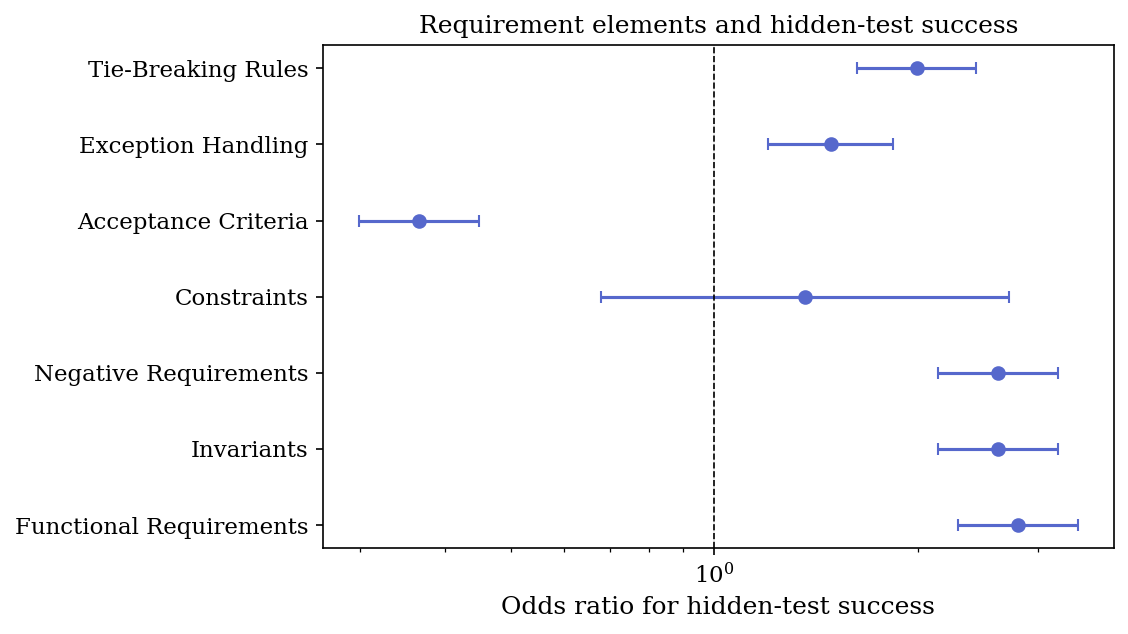

In [5]:
# Forest plot for estimable single-element ORs.
forest = models[(models['status'] == 'ok') & (models['model'].str.startswith('single_'))].copy()
if not forest.empty:
    forest['label'] = forest['predictor'].map(REQ_LABELS)
    forest = forest.set_index('predictor').loc[[c for c in HEATMAP_ORDER if c in forest['predictor'].values]].reset_index()
    y = np.arange(len(forest))
    fig, ax = plt.subplots(figsize=(6.8, max(3.2, 0.45*len(forest)+1.2)))
    ax.errorbar(forest['odds_ratio'], y,
                xerr=[forest['odds_ratio']-forest['ci_low'], forest['ci_high']-forest['odds_ratio']],
                fmt='o', color='#5668cc', ecolor='#5668cc', capsize=3)
    ax.axvline(1, color='black', linewidth=0.8, linestyle='--')
    ax.set_yticks(y)
    ax.set_yticklabels(forest['label'])
    ax.set_xlabel('Odds ratio for hidden-test success')
    ax.set_xscale('log')
    ax.set_title('Requirement elements and hidden-test success')
    ax.grid(axis='x', alpha=0.25)
    fig.savefig(FIG_DIR / 'rq2_requirement_or_forest_g2g3.pdf')
    fig.savefig(FIG_DIR / 'rq2_requirement_or_forest_g2g3.png')
    plt.show()
else:
    print('No estimable single-element ORs for forest plot.')

In [6]:
# ============================================================
# Predictive power of requirement elements: table-ready ORs
# ============================================================
def _format_p(p):
    if pd.isna(p):
        return ''
    if p < 0.001:
        return '<0.001'
    return f'{p:.3f}'


def fit_single_requirement_or(data, req, outcome='failure'):
    """Fit one grouped-binomial GLM for a single requirement element.

    outcome='failure' reports odds of hidden-test failure.
    outcome='success' reports odds of hidden-test success.
    """
    d = data.dropna(subset=['hidden_passed', 'hidden_failed', req]).copy()
    row = {
        'predictor': req,
        'label': REQ_LABELS.get(req, req),
        'n_participants': len(d),
        'present_n': int(d[req].sum()) if req in d else np.nan,
        'absent_n': int((1 - d[req]).sum()) if req in d else np.nan,
        'outcome': outcome,
    }
    if d.empty:
        row.update({'status': 'no_data'})
        return row
    if d[req].nunique(dropna=True) < 2:
        row.update({'status': 'not_estimable_constant_predictor'})
        return row
    try:
        X = sm.add_constant(d[[req]], has_constant='add')
        if outcome == 'failure':
            y = np.column_stack([d['hidden_failed'], d['hidden_passed']])
        elif outcome == 'success':
            y = np.column_stack([d['hidden_passed'], d['hidden_failed']])
        else:
            raise ValueError("outcome must be 'failure' or 'success'")
        res = sm.GLM(y, X, family=sm.families.Binomial()).fit(maxiter=200)
        ci_low, ci_high = res.conf_int().loc[req]
        row.update({
            'status': 'ok',
            'coef': res.params[req],
            'odds_ratio': np.exp(res.params[req]),
            'ci_low': np.exp(ci_low),
            'ci_high': np.exp(ci_high),
            'p_value': res.pvalues[req],
            'aic': res.aic,
        })
        return row
    except Exception as e:
        row.update({'status': f'error: {type(e).__name__}: {e}'})
        return row

# Main paper-facing table: odds of hidden-test failure.
predictive_failure = pd.DataFrame([
    fit_single_requirement_or(df, req, outcome='failure') for req in HEATMAP_ORDER
])

# Companion table: odds of hidden-test success.
predictive_success = pd.DataFrame([
    fit_single_requirement_or(df, req, outcome='success') for req in HEATMAP_ORDER
])

for tab in [predictive_failure, predictive_success]:
    if 'p_value' in tab.columns:
        ok = tab['p_value'].notna()
        if ok.any():
            tab.loc[ok, 'p_adj_bh'] = multipletests(tab.loc[ok, 'p_value'], method='fdr_bh')[1]
        tab['p_value_fmt'] = tab['p_value'].apply(_format_p)
        tab['p_adj_bh_fmt'] = tab['p_adj_bh'].apply(_format_p) if 'p_adj_bh' in tab.columns else ''

# Table-ready compact version: rounded values and formatted p-values.
predictive_table_ready = predictive_failure[predictive_failure['status'].eq('ok')].copy()
predictive_table_ready = predictive_table_ready[[
    'label', 'odds_ratio', 'ci_low', 'ci_high', 'p_value', 'p_value_fmt',
    'p_adj_bh', 'p_adj_bh_fmt', 'present_n', 'absent_n'
]]
predictive_table_ready[['odds_ratio', 'ci_low', 'ci_high']] = predictive_table_ready[
    ['odds_ratio', 'ci_low', 'ci_high']
].round(2)
predictive_table_ready['p_value'] = predictive_table_ready['p_value'].round(3)
predictive_table_ready['p_adj_bh'] = predictive_table_ready['p_adj_bh'].round(3)

# Keep heatmap order for direct paper use.
predictive_table_ready['order'] = predictive_table_ready['label'].map({
    REQ_LABELS[c]: i for i, c in enumerate(HEATMAP_ORDER)
})
predictive_table_ready = predictive_table_ready.sort_values('order').drop(columns='order')

# Export all versions.
predictive_failure.to_csv(TAB_DIR / 'rq2_requirement_predictive_power_failure_odds.csv', index=False)
predictive_success.to_csv(TAB_DIR / 'rq2_requirement_predictive_power_success_odds.csv', index=False)
predictive_table_ready.to_csv(TAB_DIR / 'rq2_requirement_predictive_power_table_ready.csv', index=False)

# LaTeX-ready table body.
latex_table = predictive_table_ready.copy()
latex_table['OR [95% CI]'] = latex_table.apply(
    lambda r: f"{r['odds_ratio']:.2f} [{r['ci_low']:.2f}, {r['ci_high']:.2f}]", axis=1
)
latex_table['$p$'] = latex_table['p_value_fmt']
latex_export = latex_table[['label', 'OR [95% CI]', '$p$', 'present_n', 'absent_n']]
latex_export.to_csv(TAB_DIR / 'rq2_requirement_predictive_power_latex_ready.csv', index=False)

print('Table-ready values: hidden-test failure odds')
display(predictive_table_ready)
print('\nCompanion values: hidden-test success odds')
display(predictive_success[['label','odds_ratio','ci_low','ci_high','p_value','p_adj_bh','present_n','absent_n','status']])

Table-ready values: hidden-test failure odds


,label,odds_ratio,ci_low,ci_high,p_value,p_value_fmt,p_adj_bh,p_adj_bh_fmt,present_n,absent_n
0,Functional Requirements,0.36,0.29,0.44,0.000,<0.001,0.000,<0.001,24,24
1,Invariants,0.38,0.31,0.47,0.000,<0.001,0.000,<0.001,23,25
2,Negative Requirements,0.38,0.31,0.47,0.000,<0.001,0.000,<0.001,23,25
3,Constraints,0.74,0.37,1.47,0.384,0.384,0.384,0.384,47,1
4,Acceptance Criteria,2.73,2.23,3.35,0.000,<0.001,0.000,<0.001,23,25
5,Exception Handling,0.67,0.55,0.83,0.000,<0.001,0.000,<0.001,16,32
6,Tie-Breaking Rules,0.50,0.41,0.62,0.000,<0.001,0.000,<0.001,21,27



Companion values: hidden-test success odds


,label,odds_ratio,ci_low,ci_high,p_value,p_adj_bh,present_n,absent_n,status
0,Functional Requirements,2.804121,2.286654,3.438690,3.906601e-23,2.734621e-22,24,24,ok
1,Invariants,2.621730,2.138714,3.213831,1.742328e-20,3.049075e-20,23,25,ok
2,Negative Requirements,2.621730,2.138714,3.213831,1.742328e-20,3.049075e-20,23,25,ok
3,Constraints,1.360110,0.680544,2.718267,3.839812e-01,3.839812e-01,47,1,ok
4,Acceptance Criteria,0.366097,0.298659,0.448762,3.906130e-22,1.367145e-21,23,25,ok
5,Exception Handling,1.484059,1.201141,1.833616,2.539295e-04,2.962511e-04,16,32,ok
6,Tie-Breaking Rules,1.989437,1.624656,2.436122,2.818131e-11,3.945383e-11,21,27,ok


## 4. Requirement--failure-mode risk-difference contrasts

For each requirement element and failure mode, we compute:

\[
\Delta_{c,f}=P(Fail_f \mid Req_c=0)-P(Fail_f \mid Req_c=1)
\]

Positive values indicate lower failure-mode prevalence when the requirement element is present.

In [ ]:
# ============================================================
# Failure-mode mapping and participant-level failure modes
# ============================================================
FAILURE_MODE_DIR = PROJECT_ROOT / "Data" / "failure_mode_maps"

task_a_path = (
    FAILURE_MODE_DIR
    / "hidden_test_failure_mode_labels_TaskA.json"
)

task_b_path = (
    FAILURE_MODE_DIR
    / "hidden_test_failure_mode_labels_TaskB.json"
)

# Confirm that the required files exist.
for file_path in [task_a_path, task_b_path]:
    if not file_path.is_file():
        raise FileNotFoundError(
            f"Failure-mode mapping file not found: {file_path}"
        )

with task_a_path.open("r", encoding="utf-8") as file:
    task_a_modes = json.load(file)

with task_b_path.open("r", encoding="utf-8") as file:
    task_b_modes = json.load(file)


def print_failure_mode_counts(task_name, failure_mode_map):
    """Print total tests and the number assigned to each failure mode."""
    mode_counts = (
        pd.Series(failure_mode_map.values())
        .value_counts()
        .sort_index()
    )

    print(f"\n{task_name}")
    print(f"Mapped tests: {len(failure_mode_map)}")
    print(f"Unique failure modes: {mode_counts.size}")
    print("Tests per failure mode:")

    for mode, count in mode_counts.items():
        print(f"  {mode}: {count}")


print(f"Loaded Task A failure modes from: {task_a_path}")
print_failure_mode_counts("Task A", task_a_modes)

print(f"\nLoaded Task B failure modes from: {task_b_path}")
print_failure_mode_counts("Task B", task_b_modes)


Task A
Mapped tests: 30
Unique failure modes: 5
Tests per failure mode:
  AI: 6
  CO: 9
  EC: 9
  IV: 5
  TB: 1

Task B
Mapped tests: 33
Unique failure modes: 4
Tests per failure mode:
  AI: 9
  CO: 14
  EC: 6
  IV: 4


In [14]:


MODE_ORDER = ['CO', 'IV', 'TB', 'EC', 'AI']

def split_tests(s):
    if pd.isna(s) or str(s).strip() == '':
        return []
    return [x.strip() for x in str(s).split(';') if x.strip()]

def normalize_test_name(test_name):
    # Remove pytest parameter suffix, e.g., test_TC30_x[45-False] -> test_TC30_x
    return re.sub(r'\[.*\]$', '', str(test_name).strip())

def mode_for_test(task, test_name):
    base = normalize_test_name(test_name)
    if str(task).upper() == 'A':
        return task_a_modes.get(base)
    if str(task).upper() == 'B':
        return task_b_modes.get(base)
    return None

failure_rows = []
for _, row in df.iterrows():
    failed = split_tests(row.get('failed_tests_phase1', ''))
    mode_counts = {m: 0 for m in MODE_ORDER}
    unknown_tests = []
    for test in failed:
        mode = mode_for_test(row['task'], test)
        if mode in mode_counts:
            mode_counts[mode] += 1
        else:
            unknown_tests.append(test)
    rec = {
        'participant_id': row['participant_id'],
        'specification': row['specification'],
        'task': row['task'],
        'unknown_failed_tests': ';'.join(unknown_tests),
    }
    for mode in MODE_ORDER:
        rec[f'fail_{mode}'] = int(mode_counts[mode] > 0)
        rec[f'fail_count_{mode}'] = mode_counts[mode]
    failure_rows.append(rec)

failure_df = pd.DataFrame(failure_rows)
analysis_df = df.merge(failure_df, on=['participant_id','specification','task'], how='left')
failure_df.to_csv(TAB_DIR / 'rq2_failure_mode_participant_summary_g2g3.csv', index=False)

unknown = failure_df['unknown_failed_tests'].replace('', np.nan).dropna()
print(f'Participants with unmapped failed tests: {unknown.shape[0]}')
if unknown.shape[0] > 0:
    display(unknown.head())

Participants with unmapped failed tests: 0


In [15]:
# ============================================================
# Risk-difference contrasts
# ============================================================
risk_rows = []
for req in REQ_COLS:
    for mode in MODE_ORDER:
        fail_col = f'fail_{mode}'
        d = analysis_df[[req, fail_col]].dropna().copy()
        n0 = int((d[req] == 0).sum())
        n1 = int((d[req] == 1).sum())
        if n0 == 0 or n1 == 0:
            rd = np.nan
            p0 = np.nan
            p1 = np.nan
            status = 'not_estimable_no_contrast_group'
        else:
            p0 = d.loc[d[req] == 0, fail_col].mean()
            p1 = d.loc[d[req] == 1, fail_col].mean()
            rd = p0 - p1
            status = 'ok'
        risk_rows.append({
            'requirement': req,
            'requirement_label': REQ_LABELS[req],
            'failure_mode': mode,
            'risk_difference': rd,
            'P_fail_req_absent': p0,
            'P_fail_req_present': p1,
            'n_req_absent': n0,
            'n_req_present': n1,
            'status': status,
        })

risk = pd.DataFrame(risk_rows)
risk.to_csv(TAB_DIR / 'rq2_requirement_failure_risk_differences_g2g3.csv', index=False)

matrix = risk.pivot(index='requirement', columns='failure_mode', values='risk_difference')
matrix = matrix.reindex(HEATMAP_ORDER)[MODE_ORDER]
matrix.index = [REQ_LABELS[i] for i in matrix.index]
matrix.to_csv(TAB_DIR / 'rq2_requirement_failure_heatmap_matrix_g2g3.csv')
display(matrix)

failure_mode,CO,IV,TB,EC,AI
Functional Requirements,0.041667,0.333333,0.0,0.083333,0.333333
Invariants,0.043478,0.347826,0.0,0.086957,0.347826
Negative Requirements,0.043478,0.347826,0.0,0.086957,0.347826
Constraints,0.021277,0.170213,0.0,0.042553,0.170213
Acceptance Criteria,-0.040000,-0.320000,0.0,-0.080000,-0.320000
Exception Handling,-0.031250,0.125000,0.0,-0.062500,0.125000
Tie-Breaking Rules,0.047619,0.211640,0.0,0.010582,0.211640


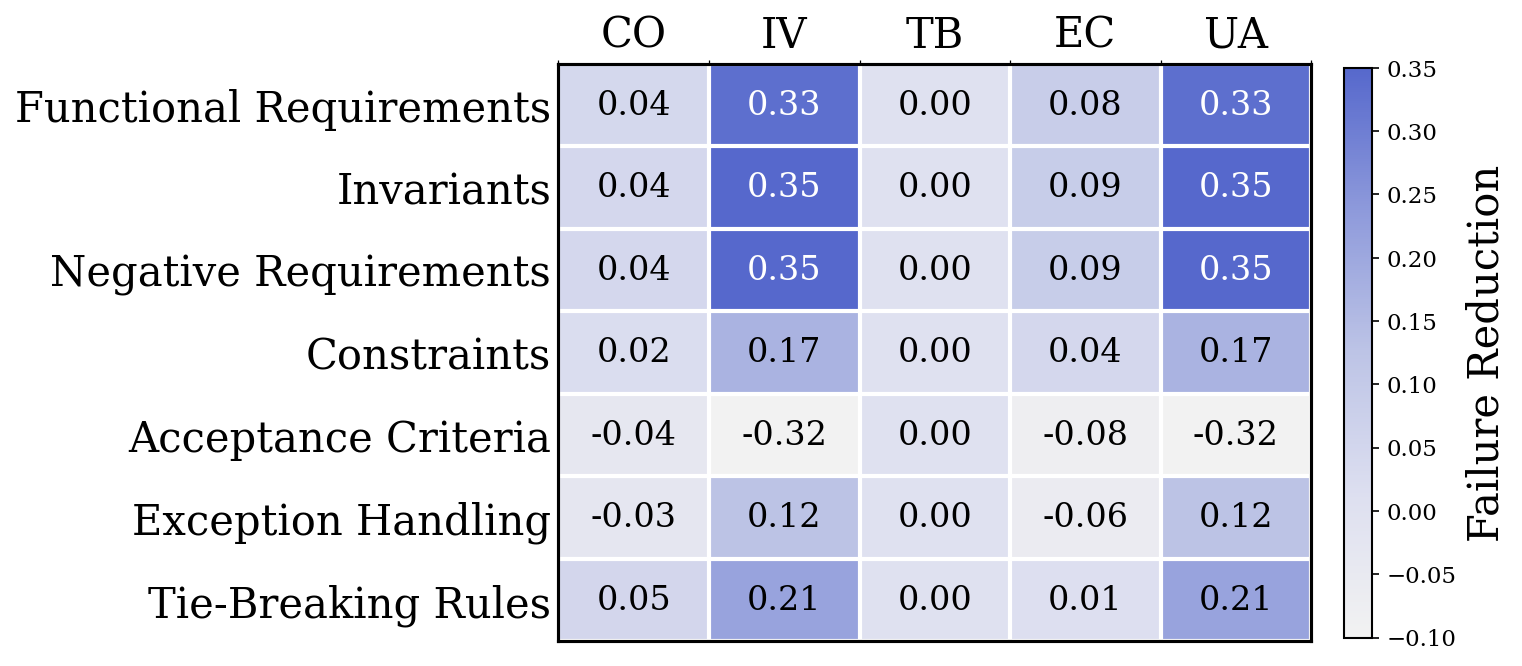

In [16]:
# Heatmap with original reference style.
fig, ax = plt.subplots(figsize=(7.0, 5.0))

vals = np.ma.masked_invalid(matrix.to_numpy(dtype=float))
im = ax.imshow(
    vals,
    cmap=ORIGINAL_HEATMAP_CMAP,
    vmin=-0.10,
    vmax=0.35,
    aspect='auto'
)

ax.set_xticks(np.arange(len(MODE_ORDER)))
# Rename AI to UA only in the displayed x-axis labels 
mode_labels = ['UA' if mode == 'AI' else mode for mode in MODE_ORDER] 
ax.set_xticklabels(mode_labels, fontsize=20)
# ax.set_xticklabels(MODE_ORDER, fontsize=20)
ax.xaxis.tick_top()
ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False, length=0)

ax.set_yticks(np.arange(matrix.shape[0]))
ax.set_yticklabels(matrix.index, fontsize=20)

# White grid lines inside cells.
ax.set_xticks(np.arange(-.5, len(MODE_ORDER), 1), minor=True)
ax.set_yticks(np.arange(-.5, matrix.shape[0], 1), minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=2)
ax.tick_params(which='minor', bottom=False, left=False)

# Annotate cells: white font for darker backgrounds.
norm = im.norm
cmap = im.cmap

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        val = matrix.iloc[i, j]

        if pd.isna(val):
            text = 'NA'
            text_color = 'black'
        else:
            text = f'{val:.2f}'

            # Get RGBA color of this cell from the colormap.
            r, g, b, _ = cmap(norm(val))

            # Perceived brightness: lower = darker background.
            brightness = 0.299 * r + 0.587 * g + 0.114 * b
            text_color = 'white' if brightness < 0.5 else 'black'

        ax.text(
            j, i, text,
            ha='center',
            va='center',
            fontsize=16,
            color=text_color
        )

# Black border around the heatmap.
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.5)

cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.04)
cbar.set_label('Failure Reduction', rotation=90, fontsize=20)

# Black border around colorbar too.
cbar.outline.set_visible(True)
cbar.outline.set_edgecolor('black')
cbar.outline.set_linewidth(1.0)

fig.savefig(FIG_DIR / 'rq2_requirement_failure_heatmap_g2g3_original_palette.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'rq2_requirement_failure_heatmap_g2g3_original_palette.png', dpi=300, bbox_inches='tight')

plt.show()

## 5. Prompt--specification alignment

This section links specification content to LLM interaction. It summarizes whether specification elements were explicitly carried into prompts and whether alignment relates to hidden-test pass rate or failure count.

In [ ]:
# ============================================================
# Prompt--specification alignment summary
# ============================================================
align_path = (
    DATA_DIR
    / "prompt_data"
    / "Phase1_spec_alignment_summary.csv"
)

if not align_path.is_file():
    raise FileNotFoundError(
        f"Prompt-alignment file not found: {align_path}"
    )

print(f"Using alignment file: {align_path}")

if align_path.exists():
    align = pd.read_csv(align_path)
    align['participant_id'] = align['id'].astype(str)
    align_df = df[['participant_id','specification','task','hidden_passed','hidden_failed','hidden_total','pass_rate','failure_count'] + REQ_COLS].merge(
        align, on='participant_id', how='left'
    )
    align_df.to_csv(TAB_DIR / 'rq2_alignment_analysis_table_g2g3.csv', index=False)

    align_vars = [
        'alignment_score', 'omission_rate', 'explicitly_referred_to_specification',
        'carried_constraints_from_spec', 'carried_edge_cases_from_spec',
        'asked_to_preserve_invariants', 'asked_to_update_or_generate_tests_based_on_spec',
        'omitted_important_spec_elements'
    ]
    corr_rows = []
    for v in align_vars:
        if v in align_df.columns:
            d = align_df[[v, 'pass_rate', 'failure_count']].dropna()
            if len(d) >= 3 and d[v].nunique() > 1:
                rho_pass, p_pass = stats.spearmanr(d[v], d['pass_rate'])
                rho_fail, p_fail = stats.spearmanr(d[v], d['failure_count'])
            else:
                rho_pass = p_pass = rho_fail = p_fail = np.nan
            corr_rows.append({
                'alignment_variable': v,
                'n': len(d),
                'spearman_rho_pass_rate': rho_pass,
                'p_pass_rate': p_pass,
                'spearman_rho_failure_count': rho_fail,
                'p_failure_count': p_fail,
            })
    corr = pd.DataFrame(corr_rows)
    for pcol in ['p_pass_rate', 'p_failure_count']:
        mask = corr[pcol].notna()
        corr.loc[mask, pcol.replace('p_', 'p_adj_bh_')] = multipletests(corr.loc[mask, pcol], method='fdr_bh')[1]
    corr.to_csv(TAB_DIR / 'rq2_alignment_spearman_correlations_g2g3.csv', index=False)
    display(corr)
else:
    print('Alignment summary file not found:', align_path)
    align_df = None

,alignment_variable,n,spearman_rho_pass_rate,p_pass_rate,spearman_rho_failure_count,p_failure_count,p_adj_bh_pass_rate,p_adj_bh_failure_count
0,alignment_score,47,0.198700,0.180592,-0.198700,0.180592,0.361184,0.361184
1,omission_rate,47,-0.198700,0.180592,0.198700,0.180592,0.361184,0.361184
2,explicitly_referred_to_specification,47,0.630502,0.000002,-0.630502,0.000002,0.000016,0.000016
3,carried_constraints_from_spec,47,0.117148,0.432921,-0.117148,0.432921,0.494767,0.494767
4,carried_edge_cases_from_spec,47,0.126942,0.395169,-0.126942,0.395169,0.494767,0.494767
5,asked_to_preserve_invariants,47,0.337530,0.020328,-0.337530,0.020328,0.081314,0.081314
6,asked_to_update_or_generate_tests_based_on_spec,47,-0.164332,0.269683,0.164332,0.269683,0.431492,0.431492
7,omitted_important_spec_elements,47,-0.033180,0.824775,0.033180,0.824775,0.824775,0.824775


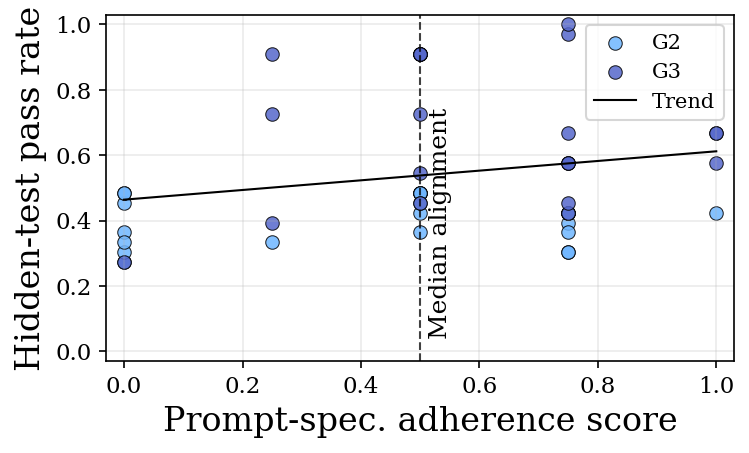

In [19]:
ALIGN_SPEC_COLORS = {
    'G2': '#6fb6ff',
    'G3': '#5668cc',
    'G2 Explicit': '#6fb6ff',
    'G3 Constraint-complete': '#5668cc',
}

fig, ax = plt.subplots(figsize=(5.4, 3.0))

# Scatter points by specification group.
for spec, sub in align_df.groupby('specification'):
    ax.scatter(
        sub['alignment_score'],
        sub['pass_rate'],
        label=spec,
        s=42,
        color=ALIGN_SPEC_COLORS.get(spec, SPEC_COLORS.get(spec, 'gray')),
        edgecolor='black',
        linewidth=0.5,
        alpha=0.85
    )

# Overall linear trend line.
trend_df = align_df.dropna(subset=['alignment_score', 'pass_rate']).copy()

if len(trend_df) >= 3 and trend_df['alignment_score'].nunique() > 1:
    x = trend_df['alignment_score'].to_numpy()
    y = trend_df['pass_rate'].to_numpy()

    coef = np.polyfit(x, y, deg=1)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = np.polyval(coef, x_line)

    ax.plot(
        x_line,
        y_line,
        color='black',
        linewidth=1.0,
        linestyle='-',
        label='Trend'
    )

# Median separation line.
median_alignment = trend_df['alignment_score'].median()

ax.axvline(
    median_alignment,
    color='black',
    linestyle='--',
    linewidth=1,
    alpha=0.75
)

ax.text(
    median_alignment + 0.015,
    0.04,
    'Median alignment',
    rotation=90,
    va='bottom',
    ha='left',
    fontsize=12,
    color='black'
)

ax.set_xlabel('Prompt-spec. adherence score', fontsize = 16)
ax.set_ylabel('Hidden-test pass rate', fontsize = 16)
# ax.set_title('Alignment and hidden-test success')

ax.set_xlim(-0.03, 1.03)
ax.set_ylim(-0.03, 1.03)

ax.grid(alpha=0.25)
ax.legend(frameon=True)

fig.savefig(FIG_DIR / 'rq2_alignment_vs_pass_rate_g2g3.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'rq2_alignment_vs_pass_rate_g2g3.png', dpi=300, bbox_inches='tight')

plt.show()

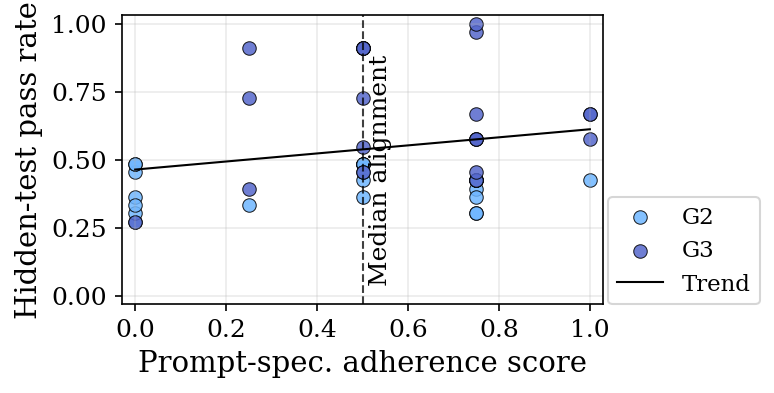

In [20]:
ALIGN_SPEC_COLORS = {
    'G2': '#6fb6ff',
    'G3': '#5668cc',
    'G2 Explicit': '#6fb6ff',
    'G3 Constraint-complete': '#5668cc',
}

fig, ax = plt.subplots(figsize=(5.4, 2.5))

# Scatter points by specification group.
for spec, sub in align_df.groupby('specification'):
    ax.scatter(
        sub['alignment_score'],
        sub['pass_rate'],
        label=spec,
        s=42,
        color=ALIGN_SPEC_COLORS.get(
            spec,
            SPEC_COLORS.get(spec, 'gray')
        ),
        edgecolor='black',
        linewidth=0.5,
        alpha=0.85
    )

# Overall linear trend line.
trend_df = align_df.dropna(
    subset=['alignment_score', 'pass_rate']
).copy()

if len(trend_df) >= 3 and trend_df['alignment_score'].nunique() > 1:
    x = trend_df['alignment_score'].to_numpy()
    y = trend_df['pass_rate'].to_numpy()

    coef = np.polyfit(x, y, deg=1)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = np.polyval(coef, x_line)

    ax.plot(
        x_line,
        y_line,
        color='black',
        linewidth=1.0,
        linestyle='-',
        label='Trend'
    )

# Median separation line.
median_alignment = trend_df['alignment_score'].median()

ax.axvline(
    median_alignment,
    color='black',
    linestyle='--',
    linewidth=1,
    alpha=0.75
)

ax.text(
    median_alignment + 0.015,
    0.04,
    'Median alignment',
    rotation=90,
    va='bottom',
    ha='left',
    fontsize=12,
    color='black'
)

# Axis labels and limits.
ax.set_xlabel(
    'Prompt-spec. adherence score',
    fontsize=14
)

ax.set_ylabel(
    'Hidden-test pass rate',
    fontsize=14
)

ax.set_xlim(-0.03, 1.03)
ax.set_ylim(-0.03, 1.03)

ax.tick_params(
    axis='both',
    labelsize=12
)

ax.grid(alpha=0.25)

# Place legend outside the chart area on the right.
ax.legend(
    loc='best',
    bbox_to_anchor=(1.01, 0.37),
    frameon=True,
    borderaxespad=0,
    fontsize=11
)

# Reserve room for the external legend.
fig.subplots_adjust(right=0.72)

fig.savefig(
    FIG_DIR / 'rq2_alignment_vs_pass_rate_g2g3_legend_out.pdf',
    bbox_inches='tight'
)

fig.savefig(
    FIG_DIR / 'rq2_alignment_vs_pass_rate_g2g3_legend_out.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## 6. Prompt type

Prompt type complements alignment: alignment captures whether participants carried specification content into the LLM interaction, while prompt type captures how they used the LLM (clarification, code generation, debugging, test generation, or other).

prompt_type,clarification,code_generation,debugging,test_generation,other
specification,,,,,
G2,0.261682,0.0,0.233645,0.0,0.504673
G3,0.344538,0.0,0.109244,0.0,0.546218


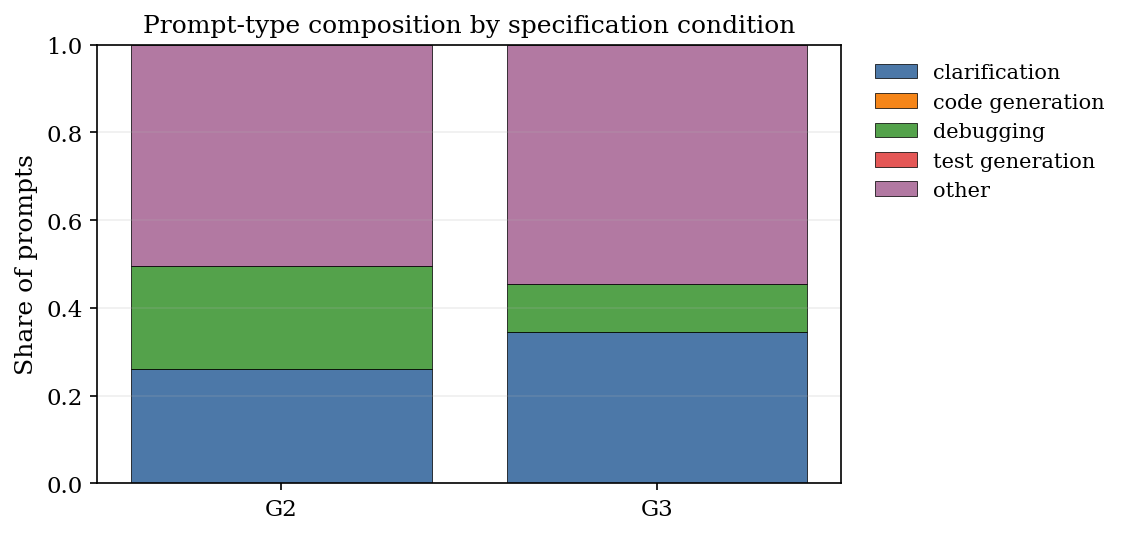

,prompt_type_variable,outcome,n,spearman_rho,p_value,p_adj_bh
0,clarification,pass_rate,47,0.022027,0.883164,0.883164
1,clarification,failure_count,47,-0.022027,0.883164,0.883164
2,clarification,alignment_score,47,0.029491,0.844003,0.883164
3,clarification,omission_rate,47,-0.029491,0.844003,0.883164
4,code_generation,pass_rate,47,NaN,NaN,NaN
5,code_generation,failure_count,47,NaN,NaN,NaN
6,code_generation,alignment_score,47,NaN,NaN,NaN
7,code_generation,omission_rate,47,NaN,NaN,NaN
8,debugging,pass_rate,47,-0.236303,0.109792,0.439168
9,debugging,failure_count,47,0.236303,0.109792,0.439168


In [22]:
# ============================================================
# Prompt type summaries
# ============================================================
def parse_prompt_category(x):
    if pd.isna(x):
        return 'other'
    s = str(x).strip()
    try:
        obj = json.loads(s)
        cat = obj.get('category', 'other')
    except Exception:
        try:
            obj = ast.literal_eval(s)
            cat = obj.get('category', 'other') if isinstance(obj, dict) else s
        except Exception:
            cat = s
    cat = str(cat).strip().lower().replace(' ', '_')
    if cat not in PROMPT_TYPE_COLORS:
        cat = 'other'
    return cat

# ============================================================
# Prompt type and prompt summary files
# ============================================================
prompt_type_path = (
    DATA_DIR
    / "prompt_data"
    / "Phase1_prompt_type.csv"
)

prompt_summary_path = (
    DATA_DIR
    / "prompt_data"
    / "Phase1_prompt_summary.csv"
)

# Confirm that both files exist.
for file_path in [prompt_type_path, prompt_summary_path]:
    if not file_path.is_file():
        raise FileNotFoundError(
            f"Prompt data file not found: {file_path}"
        )

# print(f"Using prompt type file: {prompt_type_path}")
# print(f"Using prompt summary file: {prompt_summary_path}")

if prompt_type_path.exists():
    pt = pd.read_csv(prompt_type_path)
    pt = pt[pt['specification'].isin(['G2','G3'])].copy()
    pt['participant_id'] = pt['id'].astype(str)
    pt['prompt_type'] = pt['prompt_category'].apply(parse_prompt_category)
    pt_counts = pt.groupby(['participant_id','specification','Task','prompt_type']).size().unstack(fill_value=0).reset_index()
    for cat in PROMPT_TYPE_COLORS:
        if cat not in pt_counts.columns:
            pt_counts[cat] = 0
    pt_counts['total_prompts_from_type_file'] = pt_counts[list(PROMPT_TYPE_COLORS)].sum(axis=1)
    for cat in PROMPT_TYPE_COLORS:
        pt_counts[f'{cat}_share'] = np.where(pt_counts['total_prompts_from_type_file'] > 0,
                                            pt_counts[cat] / pt_counts['total_prompts_from_type_file'], np.nan)
    pt_counts.to_csv(TAB_DIR / 'rq2_prompt_type_counts_g2g3.csv', index=False)

    prompt_analysis = df[['participant_id','specification','task','pass_rate','failure_count','hidden_passed','hidden_failed'] + REQ_COLS].merge(
        pt_counts.drop(columns=['specification','Task'], errors='ignore'), on='participant_id', how='left'
    )
    if align_df is not None:
        keep_align = ['participant_id','alignment_score','omission_rate','specified_element_categories_appeared','specified_element_categories_omitted']
        keep_align = [c for c in keep_align if c in align_df.columns]
        prompt_analysis = prompt_analysis.merge(align_df[keep_align].drop_duplicates('participant_id'), on='participant_id', how='left')
    prompt_analysis.to_csv(TAB_DIR / 'rq2_prompt_process_success_table_g2g3.csv', index=False)

    # Prompt-type composition by condition.
    composition = pt_counts.groupby('specification')[list(PROMPT_TYPE_COLORS)].sum()
    composition_share = composition.div(composition.sum(axis=1), axis=0)
    composition_share.to_csv(TAB_DIR / 'rq2_prompt_type_composition_by_group_g2g3.csv')
    display(composition_share)

    fig, ax = plt.subplots(figsize=(6.4, 3.8))
    bottom = np.zeros(len(composition_share.index))
    x = np.arange(len(composition_share.index))
    for cat in PROMPT_TYPE_COLORS:
        vals = composition_share[cat].values if cat in composition_share.columns else np.zeros(len(x))
        ax.bar(x, vals, bottom=bottom, label=cat.replace('_',' '),
               color=PROMPT_TYPE_COLORS[cat], edgecolor='black', linewidth=0.35)
        bottom += vals
    ax.set_xticks(x)
    ax.set_xticklabels(composition_share.index)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Share of prompts')
    ax.set_title('Prompt-type composition by specification condition')
    ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.grid(axis='y', alpha=0.2)
    fig.savefig(FIG_DIR / 'rq2_prompt_type_composition_by_group_g2g3.pdf')
    fig.savefig(FIG_DIR / 'rq2_prompt_type_composition_by_group_g2g3.png')
    plt.show()

    # Correlations with outcomes and alignment.
    corr_vars = list(PROMPT_TYPE_COLORS) + [f'{c}_share' for c in PROMPT_TYPE_COLORS]
    outcome_vars = ['pass_rate','failure_count','alignment_score','omission_rate']
    corr_rows = []
    for v in corr_vars:
        if v in prompt_analysis.columns:
            for out in outcome_vars:
                if out in prompt_analysis.columns:
                    d = prompt_analysis[[v, out]].dropna()
                    if len(d) >= 3 and d[v].nunique() > 1:
                        rho, p = stats.spearmanr(d[v], d[out])
                    else:
                        rho, p = np.nan, np.nan
                    corr_rows.append({'prompt_type_variable': v, 'outcome': out, 'n': len(d), 'spearman_rho': rho, 'p_value': p})
    pt_corr = pd.DataFrame(corr_rows)
    if 'p_value' in pt_corr.columns:
        mask = pt_corr['p_value'].notna()
        pt_corr.loc[mask, 'p_adj_bh'] = multipletests(pt_corr.loc[mask, 'p_value'], method='fdr_bh')[1]
    pt_corr.to_csv(TAB_DIR / 'rq2_prompt_type_spearman_correlations_g2g3.csv', index=False)
    display(pt_corr)
else:
    print('Prompt type file not found:', prompt_type_path)

## 7. Export outputs

In [23]:
# Save a compact JSON summary for quick inspection.
summary = {
    'n_participants_g2g3': int(len(df)),
    'specification_counts': df['specification'].value_counts().to_dict(),
    'task_counts': df['task'].value_counts().to_dict(),
    'requirement_presence_overall': {REQ_LABELS[c]: int(df[c].sum()) for c in REQ_COLS},
    'outputs_directory': str(OUT_DIR),
}
with open(OUT_DIR / 'rq2_phase1_g2g3_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
summary

{'n_participants_g2g3': 48,
 'specification_counts': {'G2': 24, 'G3': 24},
 'task_counts': {'B': 24, 'A': 24},
 'requirement_presence_overall': {'Acceptance Criteria': 23,
  'Functional Requirements': 24,
  'Invariants': 23,
  'Negative Requirements': 23,
  'Constraints': 47,
  'Exception Handling': 16,
  'Tie-Breaking Rules': 21},
 'outputs_directory': 'rq2_outputs'}